# Data Information

This dataset contains medical insurance cost information for 1338 individuals. It includes demographic and health-related variables such as age, sex, BMI, number of children, smoking status, and residential region in the US. The target variable is charges, which represents the medical insurance cost billed to the individual.

Source: https://doi.org/10.34740/kaggle/dsv/12853160

# Dataset

In [1]:
import pandas as pd

data_df = pd.read_csv("insurance.csv")
data_df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


# Problem Definition

## Objective

- use the dataset to estimate insurance bill/cost per person
- identify which variables are most associated with higher or lower insurance bill

## Usecase

Corporate Wellness Program
- Identify high-risk employees based on predicted healthcare costs
- Enable targeted interventions to reduce the company’s overall healthcare expenses

Insurance Company
- Analyze healthcare cost trends across different population segments
- Enable dynamic premium pricing based on individual risk profiles
- Provide personalized insurance plans tailored to each customer

Example Use Case
A person with certain conditions who is predicted to have high healthcare costs can be recommended lifestyle interventions

# Data Preparation

## 1. Data Understanding

In [2]:
print("Shape:", data_df.shape)

Shape: (1338, 7)


In [3]:
print("Columns:", data_df.columns)

Columns: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')


In [4]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
data_df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
data_df.duplicated().sum()

np.int64(1)

In [7]:
data_df = data_df.drop_duplicates()
data_df.duplicated().sum()

np.int64(0)

In [8]:
data_df.describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


In [9]:
data_df.describe(include="str")

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


# 2. Data Cleaning

## 2.1 Outlier 

In [10]:
num_cols = ['age', 'bmi', 'charges']

for col in num_cols:
    Q1 = data_df[col].quantile(0.25)
    Q3 = data_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data_df[(data_df[col] < lower) | (data_df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
charges: 139 outliers


The BMI outlier in this dataset is above ~47.3 (upper bound IQR), with a max of 53.13. Although these values fall within the Obesity Class III category which medically exists, they are extreme values that can disproportionately influence the linear regression model. These 9 outliers will be dropped to improve model robustness.

Outlier charges are retained because they are the target variable that the model must predict.

In [ ]:
Q1 = data_df['bmi'].quantile(0.25)
Q3 = data_df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(data_df)
data_df = data_df[(data_df['bmi'] >= lower) & (data_df['bmi'] <= upper)]
after = len(data_df)

print(f"Dropped {before - after} BMI outliers (BMI > {upper:.1f})")
print(f"Remaining samples: {after}")

In [11]:
data_df['children'].value_counts()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [12]:
data_df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [13]:
data_df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [14]:
data_df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

# 3. Data Transformation

## 3.1 Feature Encoding

In [15]:
data_df['gender_encoded'] = data_df['sex'].map({'male': 0, 'female': 1})
data_df.head(5)

,age,sex,bmi,children,smoker,region,charges,gender_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [16]:
data_df['smoker_encoded'] = data_df['smoker'].map({'no': 0, 'yes': 1})
data_df.head(5)

,age,sex,bmi,children,smoker,region,charges,gender_encoded,smoker_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,1,1
1,18,male,33.770,1,no,southeast,1725.55230,0,0
2,28,male,33.000,3,no,southeast,4449.46200,0,0
3,33,male,22.705,0,no,northwest,21984.47061,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0


In [17]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' opsional

region_encoded = encoder.fit_transform(data_df[['region']])

region_columns = encoder.get_feature_names_out(['region'])
region_df = pd.DataFrame(region_encoded, columns=region_columns, index=data_df.index)

data_df = data_df.drop('region', axis=1)
data_df = pd.concat([data_df, region_df], axis=1)

data_df.head(5)

,age,sex,bmi,children,smoker,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,16884.92400,1,1,0.0,0.0,1.0
1,18,male,33.770,1,no,1725.55230,0,0,0.0,1.0,0.0
2,28,male,33.000,3,no,4449.46200,0,0,0.0,1.0,0.0
3,33,male,22.705,0,no,21984.47061,0,0,1.0,0.0,0.0
4,32,male,28.880,0,no,3866.85520,0,0,1.0,0.0,0.0


In [18]:
data_df = data_df.drop(columns=['sex', 'smoker'])
data_df.head(5)

,age,bmi,children,charges,gender_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,1,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0,0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0,0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0,0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0,0,1.0,0.0,0.0


# Data Analysis

## 1. Descriptive Statistics

In [19]:
data_df[['age', 'bmi', 'children', 'charges']].describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


## 2. Inferential Statistics

## 2.1 Normality Test

In [20]:
from scipy import stats

stat, p = stats.shapiro(data_df['charges'])
print(f"Shapiro-Wilk: stat={stat:.4f}, p-value={p:.6f}")
print(f"Skewness: {data_df['charges'].skew():.2f}")

Shapiro-Wilk: stat=0.8148, p-value=0.000000
Skewness: 1.52


Because charges are highly skewed (skewness = 1.52) and the Shapiro-Wilk test rejects normality (p < 0.05), we use non-parametric tests.

## 2.2 Binary Features VS Charges (Mann-Whitney U Test)

In [21]:
from scipy.stats import mannwhitneyu

for col in ['smoker_encoded', 'gender_encoded']:
    group_0 = data_df[data_df[col] == 0]['charges']
    group_1 = data_df[data_df[col] == 1]['charges']
    stat, p = mannwhitneyu(group_0, group_1, alternative='two-sided')
    print(f"{col}: U={stat:.2f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

smoker_encoded: U=7403.00, p-value=0.000000 --> Significant
gender_encoded: U=226198.00, p-value=0.694479 --> Not Significant


## 2.3 Multi-group Features vs Charges (Kruskal-Wallis Test)

In [22]:
from scipy.stats import kruskal

# Region
data_df['region_label'] = data_df[['region_northwest','region_southeast','region_southwest']].idxmax(axis=1)
data_df.loc[(data_df[['region_northwest','region_southeast','region_southwest']].sum(axis=1) == 0), 'region_label'] = 'region_northeast'

region_groups = [group['charges'].values for name, group in data_df.groupby('region_label')]
stat_r, p_r = kruskal(*region_groups)
print(f"region: H={stat_r:.2f}, p-value={p_r:.6f} --> {'Significant' if p_r < 0.05 else 'Not Significant'}")

# Children
children_groups = [group['charges'].values for name, group in data_df.groupby('children')]
stat_c, p_c = kruskal(*children_groups)
print(f"children: H={stat_c:.2f}, p-value={p_c:.6f} --> {'Significant' if p_c < 0.05 else 'Not Significant'}")

data_df = data_df.drop(columns=['region_label'])

region: H=4.62, p-value=0.201620 --> Not Significant
children: H=29.12, p-value=0.000022 --> Significant


## 2.4 Continuous Features vs Charges (Spearman Correlation)

In [23]:
from scipy.stats import spearmanr

for col in ['age', 'bmi']:
    corr, p = spearmanr(data_df[col], data_df['charges'])
    print(f"{col}: rho={corr:.4f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

age: rho=0.5335, p-value=0.000000 --> Significant
bmi: rho=0.1196, p-value=0.000012 --> Significant


### Inferential Statistics Summary

| Feature | Test | Statistic | p-value | Result |
|---------|------|-----------|---------|--------|
| smoker | Mann-Whitney U | U = 7,403.00 | 0.000000 | **Significant** |
| gender | Mann-Whitney U | U = 226,198.00 | 0.694479 | Not Significant |
| region | Kruskal-Wallis | H = 4.62 | 0.201620 | Not Significant |
| children | Kruskal-Wallis | H = 29.12 | 0.000022 | **Significant** |
| age | Spearman | rho = 0.5335 | 0.000000 | **Significant** (moderate +) |
| bmi | Spearman | rho = 0.1196 | 0.000012 | **Significant** (weak +) |

**Key Findings:**
- **Smoker** is the strongest predictor of charges by far (extremely low p-value)
- **Age** has a moderate positive correlation with charges -- older individuals tend to have higher costs
- **Children** has a significant effect -- the number of dependents influences insurance costs
- **BMI** has a weak but statistically significant positive correlation with charges
- **Gender** and **Region** have no significant effect on charges

## 3. Correlation

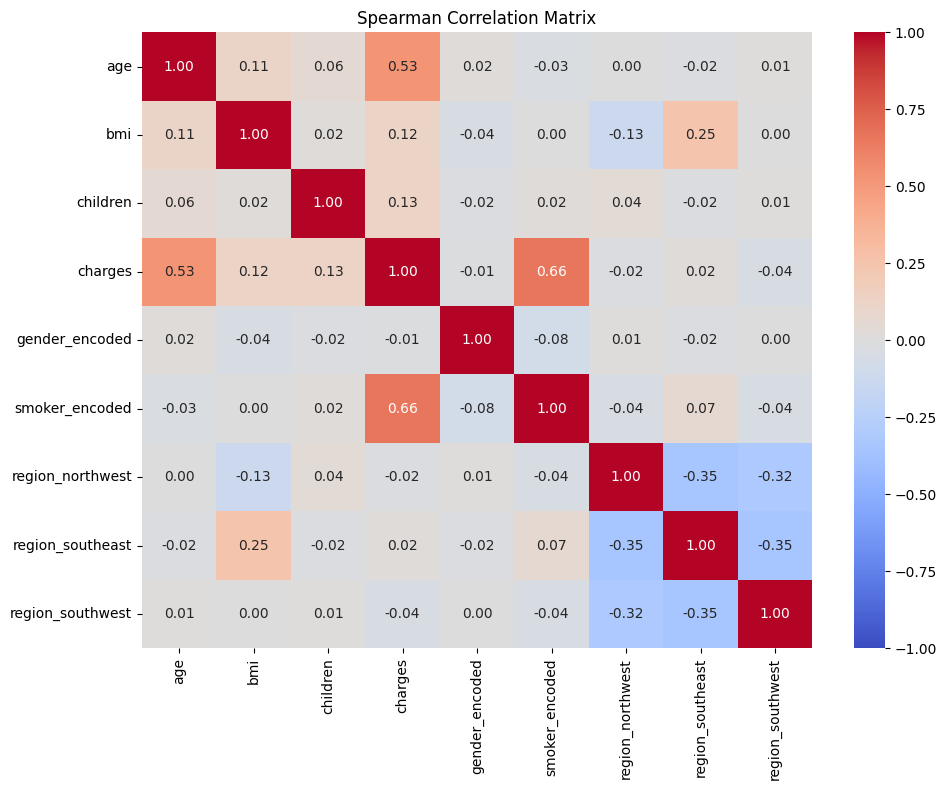

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = data_df.corr(method='spearman').round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

In [25]:
charges_corr = corr_matrix['charges'].drop('charges').sort_values(ascending=False)
print("Correlation with charges (Spearman):\n")
print(charges_corr.to_string())

Correlation with charges (Spearman):

smoker_encoded      0.66
age                 0.53
children            0.13
bmi                 0.12
region_southeast    0.02
gender_encoded     -0.01
region_northwest   -0.02
region_southwest   -0.04


# Data Visualization

In [26]:
plot_df = pd.read_csv("insurance.csv").drop_duplicates()

## 1. Distribution

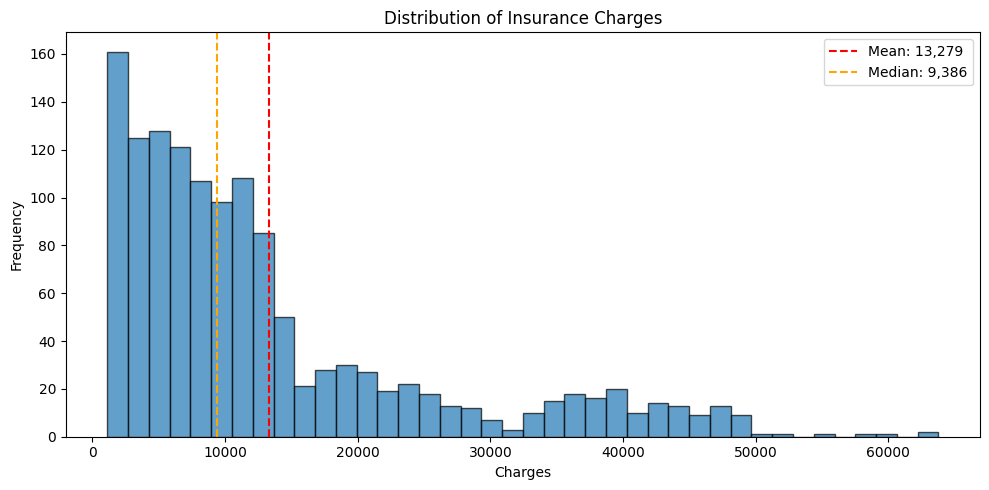

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(plot_df['charges'], bins=40, edgecolor='black', alpha=0.7)
plt.axvline(plot_df['charges'].mean(), color='red', linestyle='--', label=f"Mean: {plot_df['charges'].mean():,.0f}")
plt.axvline(plot_df['charges'].median(), color='orange', linestyle='--', label=f"Median: {plot_df['charges'].median():,.0f}")
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
numeric_cols = [
    'age',
    'bmi',
    'children'
]

categorical_cols = ['sex', 'smoker', 'region']

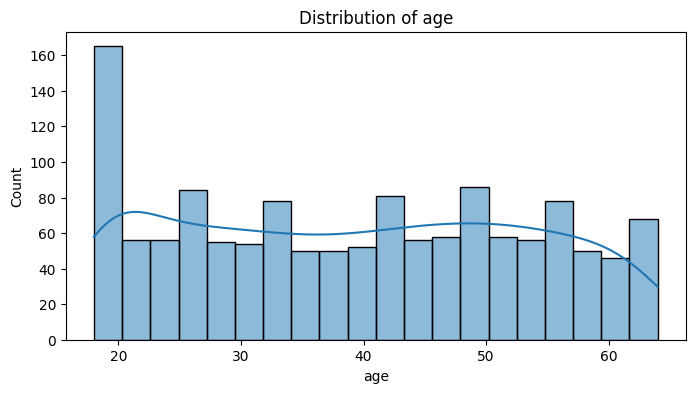

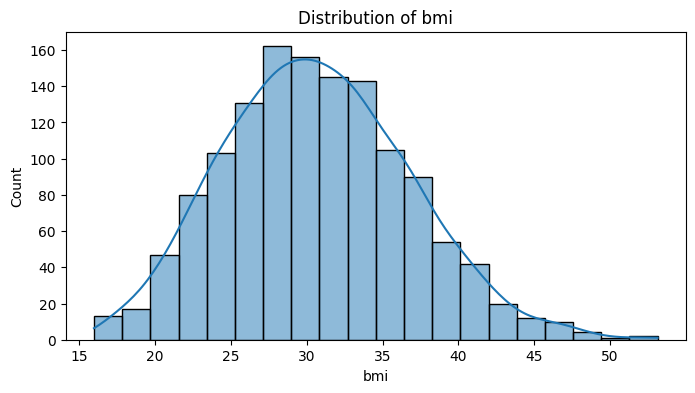

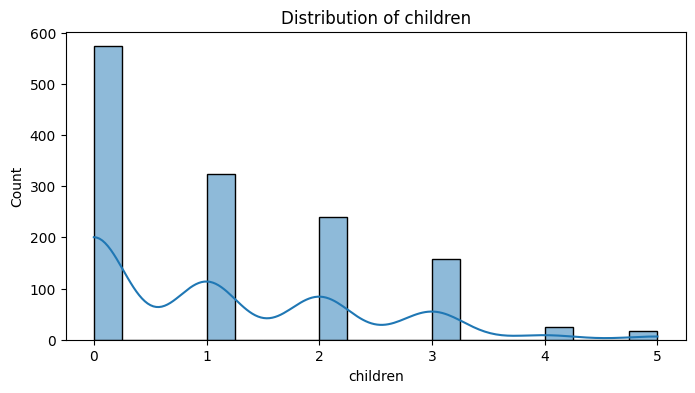

In [29]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(plot_df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

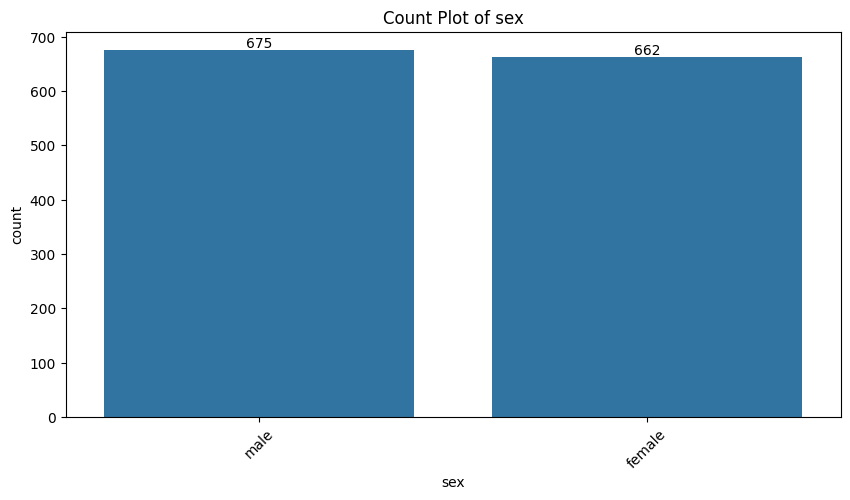

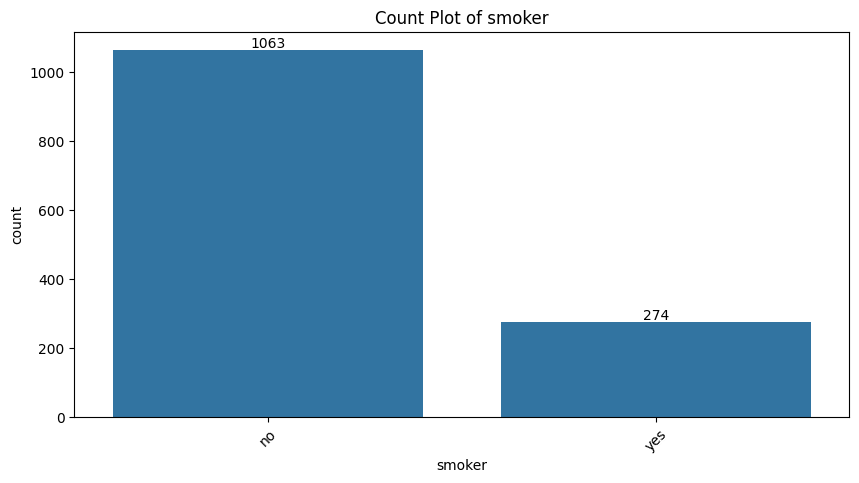

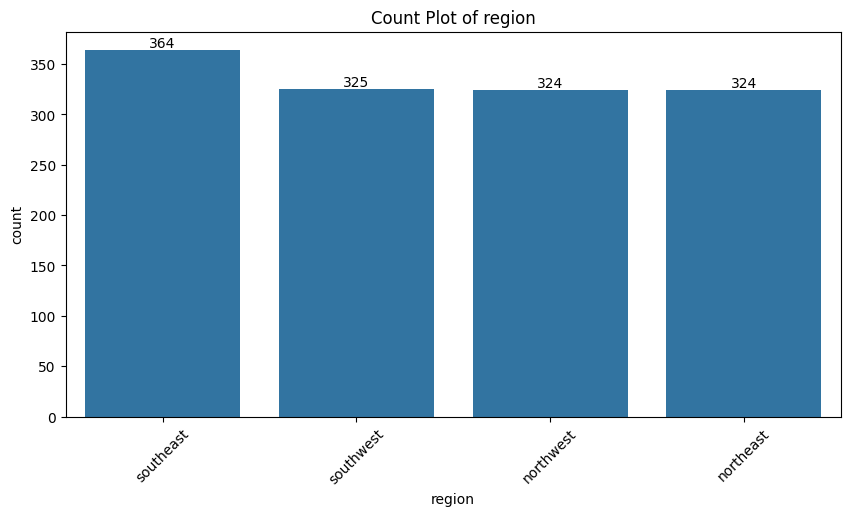

In [30]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=plot_df, x=col, order=plot_df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.show()

## 2. Charges by Smoker

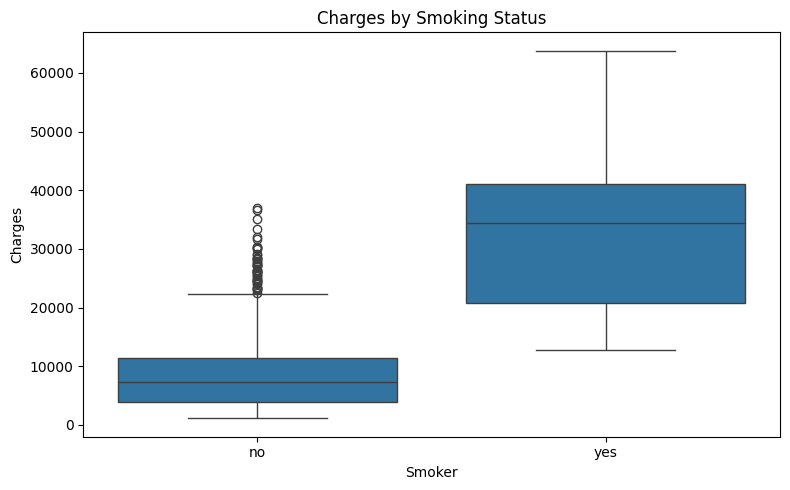

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='smoker', y='charges', order=['no', 'yes'])
plt.title('Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

## 3. Age vs Charges

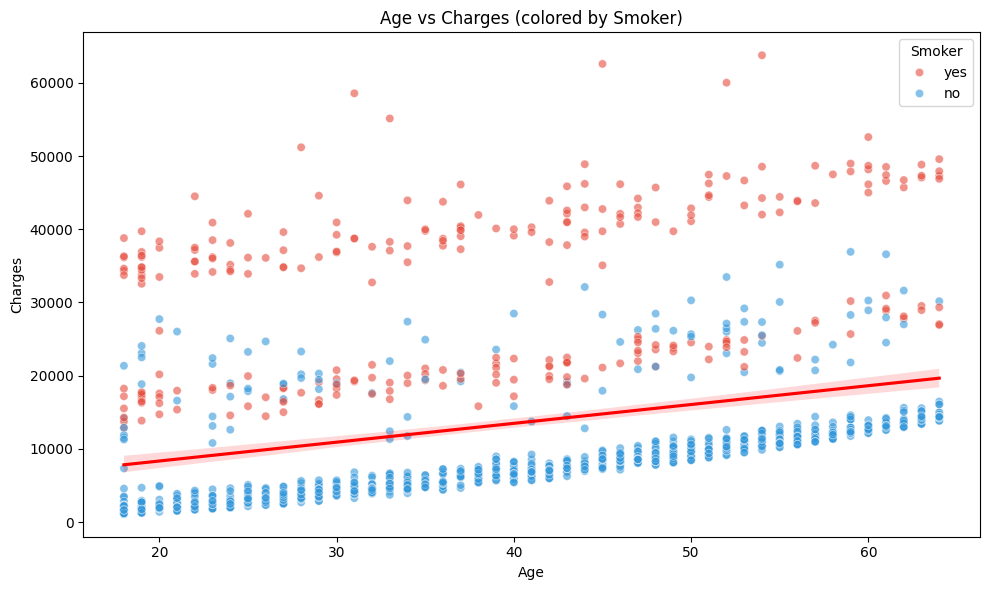

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='age', y='charges', hue='smoker', alpha=0.6, palette={'no': '#3498db', 'yes': '#e74c3c'})
sns.regplot(data=plot_df, x='age', y='charges', scatter=False, color='red')
plt.title('Age vs Charges (colored by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

## 4. BMI vs Charges

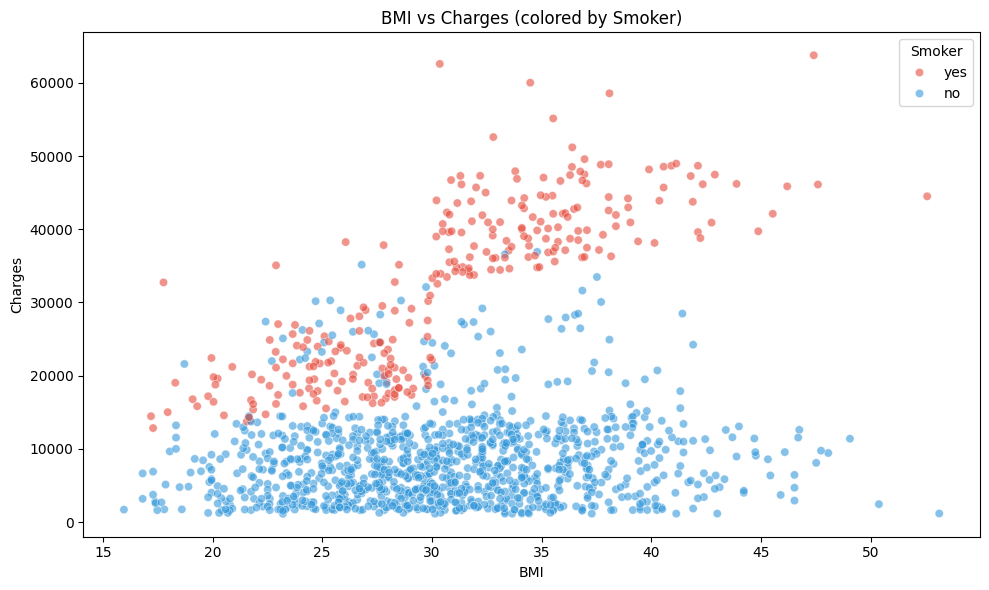

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='bmi', y='charges', hue='smoker', alpha=0.6, palette={'no': '#3498db', 'yes': '#e74c3c'})
plt.title('BMI vs Charges (colored by Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

## 5. Charges by Children

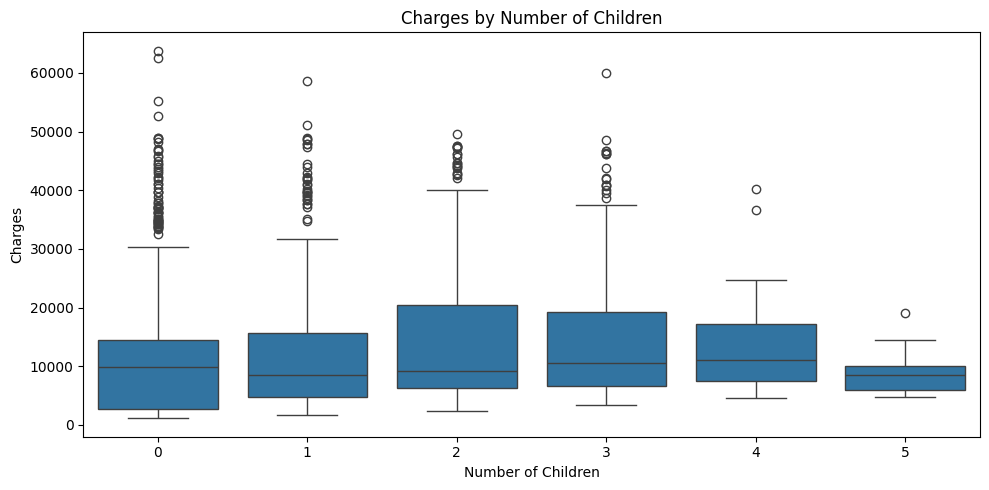

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x='children', y='charges', order=sorted(plot_df['children'].unique()))
plt.title('Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

## 6. Charges by Gender and Region

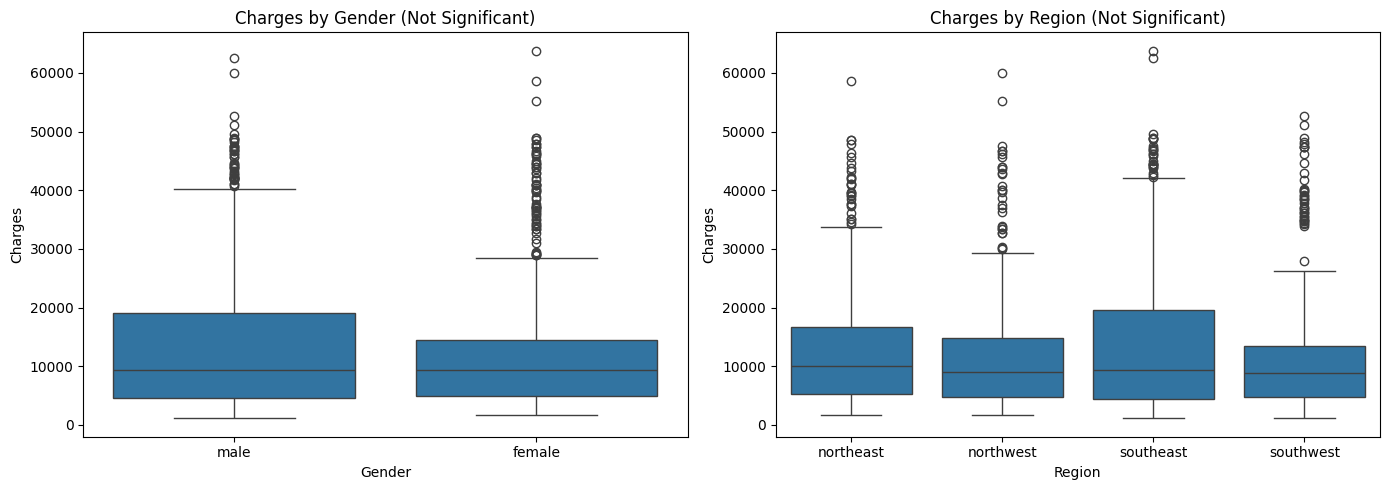

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x='sex', y='charges', order=['male', 'female'], ax=axes[0])
axes[0].set_title('Charges by Gender (Not Significant)')
axes[0].set_xlabel('Gender') 
axes[0].set_ylabel('Charges')

sns.boxplot(data=plot_df, x='region', y='charges', order=['northeast', 'northwest', 'southeast', 'southwest'], ax=axes[1])
axes[1].set_title('Charges by Region (Not Significant)')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.show()

# LINEAR REGRESSION

## 1. Data Splitting

In [36]:
from sklearn.model_selection import train_test_split

feature_cols = ['age', 'bmi', 'children', 'gender_encoded', 'smoker_encoded',
                'region_northwest', 'region_southeast', 'region_southwest']

X = data_df[feature_cols]
y = data_df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nFeatures ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

Training set: 1069 samples
Test set:     268 samples

Features (8):
  - age
  - bmi
  - children
  - gender_encoded
  - smoker_encoded
  - region_northwest
  - region_southeast
  - region_southwest


## 2. Model Training

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Linear Regression model trained successfully.")
print(f"Intercept: {model.intercept_:,.2f}")

Linear Regression model trained successfully.
Intercept: -11,194.19


## 3. Model Evaluation

In [38]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metric': ['R²', 'MSE', 'RMSE', 'MAE'],
    'Train': [r2_train, mse_train, rmse_train, mae_train],
    'Test': [r2_test, mse_test, rmse_test, mae_test]
})

metrics['Train'] = metrics['Train'].apply(lambda x: f"{x:,.4f}" if x < 10 else f"{x:,.2f}")
metrics['Test'] = metrics['Test'].apply(lambda x: f"{x:,.4f}" if x < 10 else f"{x:,.2f}")

print("Model Performance:\n")
print(metrics.to_string(index=False))

Model Performance:

Metric         Train          Test
    R²        0.7299        0.8069
   MSE 36,979,860.90 35,478,020.68
  RMSE      6,081.11      5,956.34
   MAE      4,181.90      4,177.05


## 4. Feature Coefficients

Feature Coefficients (sorted by absolute value):

  smoker_encoded            :    23,077.76
  region_southeast          :      -838.92
  region_southwest          :      -659.14
  children                  :       533.01
  region_northwest          :      -391.76
  bmi                       :       318.70
  age                       :       248.21
  gender_encoded            :       101.54


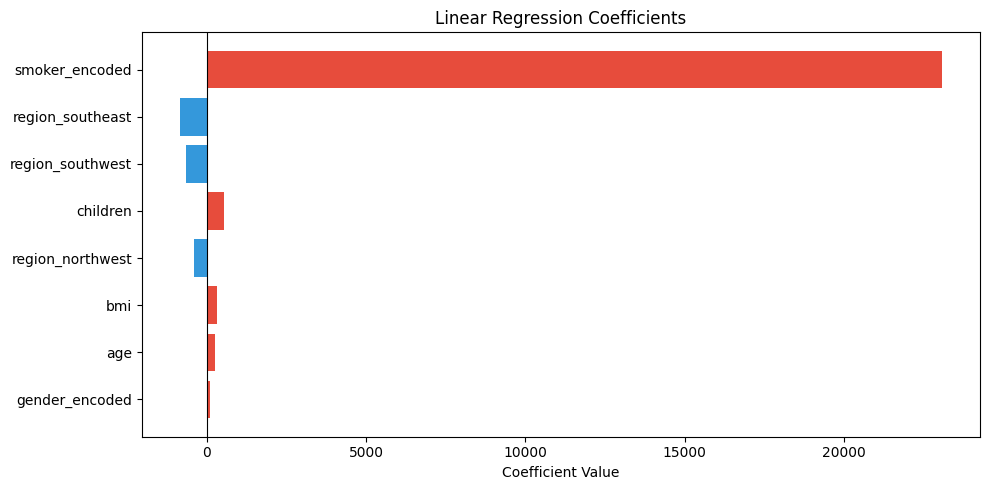

In [39]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature Coefficients (sorted by absolute value):\n")
for _, row in coef_df.iterrows():
    print(f"  {row['Feature']:25s} : {row['Coefficient']:>12,.2f}")

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression Coefficients')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Residual Analysis

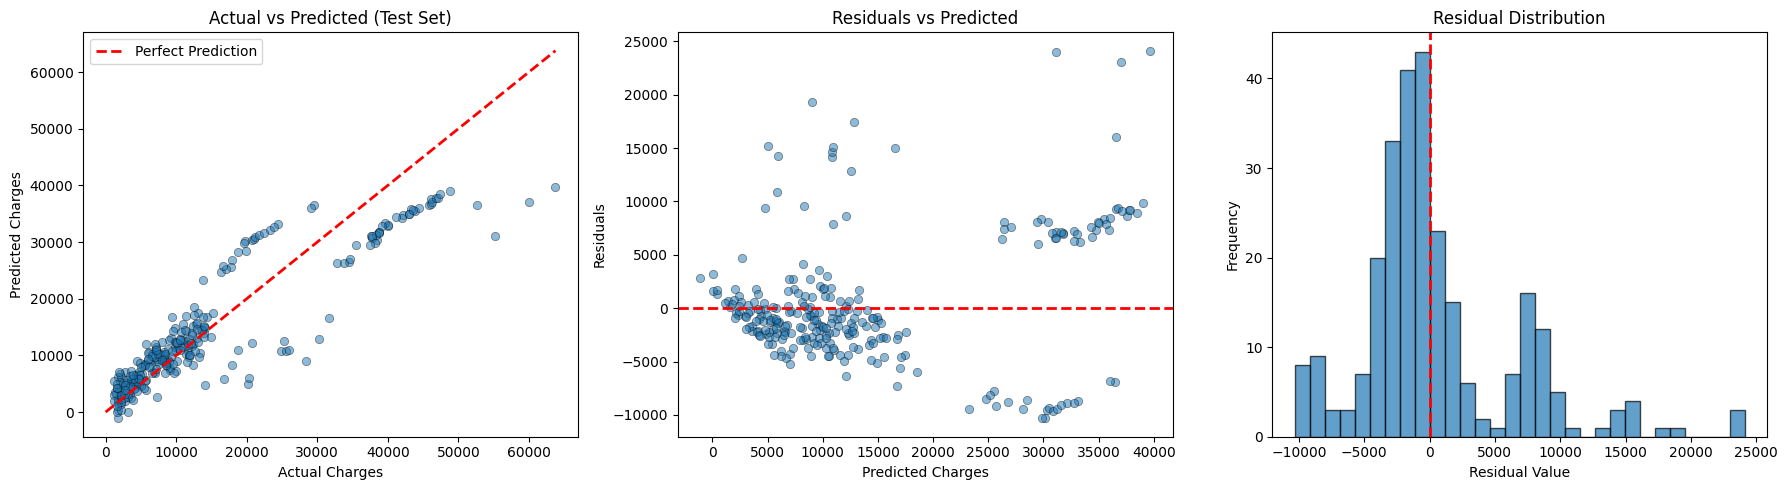

In [40]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5, edgecolors='black', linewidths=0.5)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

axes[2].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Residual Value')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## 6. Assumption Check

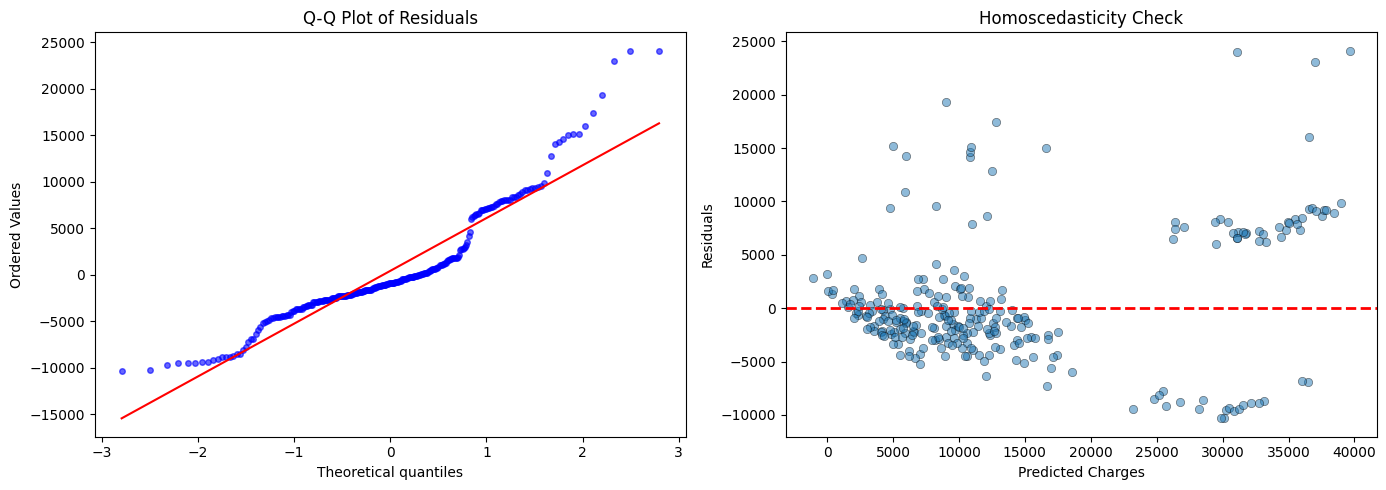


Shapiro-Wilk test on residuals:
  Statistic = 0.8977
  p-value   = 0.000000
  Result    : Residuals are NOT normally distributed

Residual Statistics:
  Mean:           425.26
  Std Dev:      5,952.26
  Skewness:       1.2425


In [41]:
from scipy.stats import shapiro
import scipy.stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot
scipy_stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot of Residuals')
axes[0].get_lines()[0].set(markersize=4, alpha=0.6)

# Residuals vs Fitted with LOWESS trend
axes[1].scatter(y_pred_test, residuals, alpha=0.5, edgecolors='black', linewidths=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Charges')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Homoscedasticity Check')

plt.tight_layout()
plt.show()

stat, p_value = shapiro(residuals)
print(f"\nShapiro-Wilk test on residuals:")
print(f"  Statistic = {stat:.4f}")
print(f"  p-value   = {p_value:.6f}")
print(f"  Result    : {'Residuals are normally distributed' if p_value > 0.05 else 'Residuals are NOT normally distributed'}")
print(f"\nResidual Statistics:")
print(f"  Mean:     {residuals.mean():>12,.2f}")
print(f"  Std Dev:  {residuals.std():>12,.2f}")
print(f"  Skewness: {residuals.skew():>12.4f}")